<a href="https://colab.research.google.com/github/NIJAMPATNAM-LATHIK-ISHANK-ARYAN/FY_Project/blob/main/Using%20Deep%20learning%20for%20Continuous%20prediction%20of%20Martality%20rate%20in%20Intensive%20Care%20Unit%20(ICU).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# importing required libraries
import numpy as np
import pandas as pd
import pickle # saving and loading trained model
from os import path

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.metrics import accuracy_score # for calculating accuracy of model
from sklearn.model_selection import train_test_split # for splitting the dataset for training and testing
from sklearn.metrics import classification_report # for generating a classification report of model

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_auc_score

In [46]:
train_data = pd.read_csv('/content/drive/MyDrive/123/data01.csv')

In [47]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1177 entries, 0 to 1176
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   group                     1177 non-null   int64  
 1   ID                        1177 non-null   int64  
 2   outcome                   1176 non-null   float64
 3   age                       1177 non-null   int64  
 4   gendera                   1177 non-null   int64  
 5   BMI                       962 non-null    float64
 6   hypertensive              1177 non-null   int64  
 7   atrialfibrillation        1177 non-null   int64  
 8   CHD with no MI            1177 non-null   int64  
 9   diabetes                  1177 non-null   int64  
 10  deficiencyanemias         1177 non-null   int64  
 11  depression                1177 non-null   int64  
 12  Hyperlipemia              1177 non-null   int64  
 13  Renal failure             1177 non-null   int64  
 14  COPD    

In [48]:
train_data["BMI"].fillna(train_data["BMI"].mean(), inplace=True)
train_data["heart rate"].fillna(train_data["heart rate"].mean(), inplace=True)
train_data["Systolic blood pressure"].fillna(train_data["Systolic blood pressure"].mean(), inplace=True)
train_data["Diastolic blood pressure"].fillna(train_data["Diastolic blood pressure"].mean(), inplace=True)
train_data["Respiratory rate"].fillna(train_data["Respiratory rate"].mean(), inplace=True)
train_data["temperature"].fillna(train_data["temperature"].mean(), inplace=True)
train_data["SP O2"].fillna(train_data["SP O2"].mean(), inplace=True)
train_data["Urine output"].fillna(train_data["Urine output"].mode()[0], inplace=True)
train_data["Neutrophils"].fillna(train_data["Neutrophils"].mean(), inplace=True)
train_data["Basophils"].fillna(train_data["Basophils"].mean(), inplace=True)
train_data["Lymphocyte"].fillna(train_data["Lymphocyte"].mean(), inplace=True)
train_data["PT"].fillna(train_data["PT"].mean(), inplace=True)
train_data["Creatine kinase"].fillna(train_data["Creatine kinase"].mean(), inplace=True)
train_data["glucose"].fillna(train_data["glucose"].mean(), inplace=True)
train_data["PH"].fillna(train_data["PH"].mean(), inplace=True)
train_data["Lactic acid"].fillna(train_data["Lactic acid"].mean(), inplace=True)
train_data["PCO2"].fillna(train_data["PCO2"].mean(), inplace=True)

In [49]:
train_data = train_data.dropna(how="any")

In [50]:
train_data.drop(["group", "ID"], axis=1, inplace=True)

In [51]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 1176
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   outcome                   1155 non-null   float64
 1   age                       1155 non-null   int64  
 2   gendera                   1155 non-null   int64  
 3   BMI                       1155 non-null   float64
 4   hypertensive              1155 non-null   int64  
 5   atrialfibrillation        1155 non-null   int64  
 6   CHD with no MI            1155 non-null   int64  
 7   diabetes                  1155 non-null   int64  
 8   deficiencyanemias         1155 non-null   int64  
 9   depression                1155 non-null   int64  
 10  Hyperlipemia              1155 non-null   int64  
 11  Renal failure             1155 non-null   int64  
 12  COPD                      1155 non-null   int64  
 13  heart rate                1155 non-null   float64
 14  Systolic bloo

In [52]:
# number of attack labels
train_data['outcome'].value_counts()

,count
outcome,
0.0,997
1.0,158


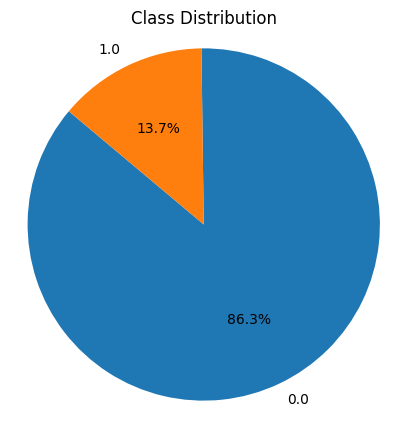

In [53]:
labels = train_data['outcome'].value_counts().index
sizes = train_data['outcome'].value_counts().values

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Class Distribution')
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

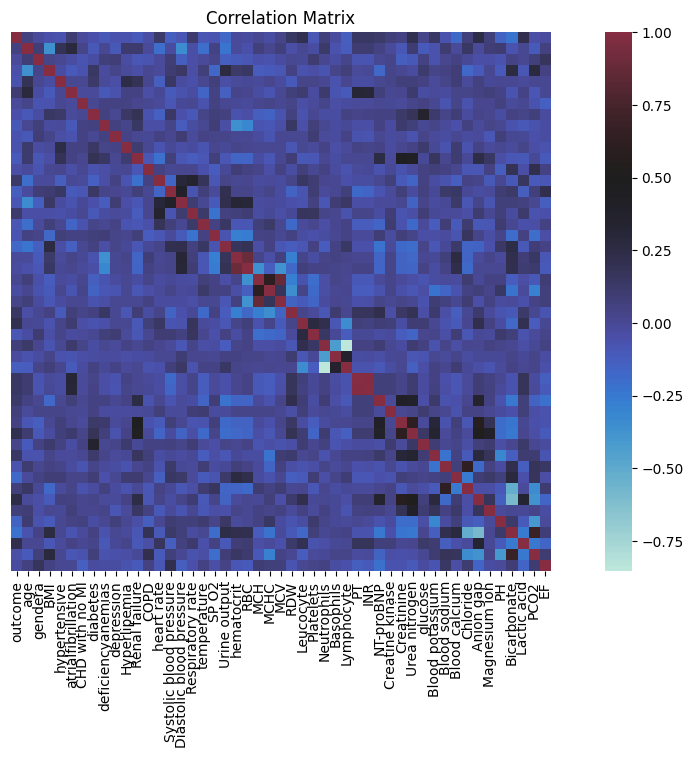

In [54]:
fig,ax=plt.subplots(1,1,figsize=(14,7))
sns.heatmap(train_data.corr(), square=True, center=0.5, yticklabels=False).set_title('Correlation Matrix')

In [56]:
X = train_data.drop(["outcome"],axis =1)
y = train_data["outcome"]

In [57]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif

selector = SelectPercentile(mutual_info_classif, percentile=35)
X_reduced = selector.fit_transform(X, y)
X_reduced.shape


(1155, 17)

In [58]:
cols = selector.get_support(indices=True)
selected_columns = X.iloc[:,cols].columns.tolist()
#selected_columns

In [59]:
df = train_data[['gendera',
 'deficiencyanemias',
 'depression',
 'COPD',
 'heart rate',
 'temperature',
 'Urine output',
 'Leucocyte',
 'Lymphocyte',
 'PT',
 'Urea nitrogen',
 'Blood sodium',
 'Anion gap',
 'PH',
 'Bicarbonate',
 'Lactic acid',
 'PCO2',
                  'outcome']]
df.to_csv('processed.csv')

# SMOTE Sampling

In [60]:
from imblearn.over_sampling import SMOTE

In [61]:
sm = SMOTE(random_state=42)

In [62]:
X_res, y_res = sm.fit_resample(X_reduced,y)

In [63]:
# splitting the dataset 80% for training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.20, random_state=42)

In [64]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []


#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_pred, y_test)
lr_prec = precision_score(y_pred, y_test,average='weighted')
lr_rec = recall_score(y_pred, y_test,average='weighted')
lr_f1 = f1_score(y_pred, y_test,average='weighted')

In [67]:
storeResults('Logistic Regression',lr_acc,lr_prec,lr_rec,lr_f1)

# Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier()
forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')

In [69]:
storeResults('Random FOrest',rf_acc,rf_prec,rf_rec,rf_f1)

# XGBoost

In [70]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=0)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_pred, y_test)
xgb_prec = precision_score(y_pred, y_test,average='weighted')
xgb_rec = recall_score(y_pred, y_test,average='weighted')
xgb_f1 = f1_score(y_pred, y_test,average='weighted')

In [71]:
storeResults('XGBoost',xgb_acc,xgb_prec,xgb_rec,xgb_f1)

# Stacking Classifier

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier

estimators = [('rf', RandomForestClassifier(n_estimators=10)),('mlp', MLPClassifier(random_state=1, max_iter=30))]

clf = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))


clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

stac_acc = accuracy_score(y_pred, y_test)
stac_prec = precision_score(y_pred, y_test,average='weighted')
stac_rec = recall_score(y_pred, y_test,average='weighted')
stac_f1 = f1_score(y_pred, y_test,average='weighted')


[LightGBM] [Info] Number of positive: 790, number of negative: 805
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 266
[LightGBM] [Info] Number of data points in the train set: 1595, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495298 -> initscore=-0.018809
[LightGBM] [Info] Start training from score -0.018809


In [73]:
storeResults('Stacking Classifier',stac_acc,stac_prec,stac_rec,stac_f1)

# Voting Classifier

In [74]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
clf1 = AdaBoostClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('ad', clf1), ('rf', clf2)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

In [75]:
storeResults('Voting Classifier',vot_acc,vot_prec,vot_rec,vot_f1)

DL

In [97]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import SimpleRNN,LSTM,GRU, Dense, Embedding, Dropout,Input, Attention, Layer, Concatenate, Permute, Dot, Multiply, Flatten
from keras.layers import RepeatVector, Dense, Activation, Lambda
from keras.models import Sequential
from keras import backend as K, regularizers, Model, metrics

In [98]:
from sklearn.preprocessing import StandardScaler
## Standardizing the data
X_r2 = StandardScaler().fit_transform(X_res)

In [99]:
X_train,X_test,y_train,y_test = train_test_split(X_r2, y_res, test_size=0.3)

In [100]:
# design network
np.random.seed(7)

# X_train et X_val sont des dataframe qui contient les features
train_X=X_train
val_X=X_test

In [101]:
## Reshape input to be 3D [samples, timesteps, features] (format requis par LSTM)
train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
val_X = val_X.reshape((val_X.shape[0], 1, val_X.shape[1]))

In [102]:
## Recuperation des labels
train_y=y_train
val_y=y_test

# RNN

In [103]:
class attention(Layer):
    def __init__(self,**kwargs):
        super(attention,self).__init__(**kwargs)

    def build(self,input_shape):
        self.W=self.add_weight(name="att_weight",shape=(input_shape[-1],1),initializer="normal")
        self.b=self.add_weight(name="att_bias",shape=(input_shape[1],1),initializer="zeros")
        super(attention, self).build(input_shape)

    def call(self,x):
        et=K.squeeze(K.tanh(K.dot(x,self.W)+self.b),axis=-1)
        at=K.softmax(et)
        at=K.expand_dims(at,axis=-1)
        output=x*at
        return K.sum(output,axis=1)

    def compute_output_shape(self,input_shape):
        return (input_shape[0],input_shape[-1])

    def get_config(self):
        return super(attention,self).get_config()

In [140]:
inputs1=Input((1,17))
att_in=SimpleRNN(50,return_sequences=True,dropout=0.3,recurrent_dropout=0.2)(inputs1)
att_in_1=SimpleRNN(50,return_sequences=True,dropout=0.3,recurrent_dropout=0.2)(att_in)
att_out=attention()(att_in_1)
outputs1=Dense(1,activation='sigmoid',trainable=True)(att_out)
model1=Model(inputs1,outputs1)

In [141]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [142]:
history=model1.fit(train_X, train_y,epochs=50,batch_size=2, validation_data=(val_X, val_y))

Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6817 - loss: 0.5968 - val_accuracy: 0.7713 - val_loss: 0.4770
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6982 - loss: 0.5704 - val_accuracy: 0.7613 - val_loss: 0.4710
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7140 - loss: 0.5599 - val_accuracy: 0.7813 - val_loss: 0.4685
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7219 - loss: 0.5393 - val_accuracy: 0.7863 - val_loss: 0.4705
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7133 - loss: 0.5492 - val_accuracy: 0.7796 - val_loss: 0.4655
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7168 - loss: 0.5419 - val_accuracy: 0.7930 - val_loss: 0.4619
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7283 - loss: 0.5376 - val_accuracy: 0.7863 - val_loss: 0.4525
Epoch 8/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7240 - loss: 0.5246 - val_accuracy:

### Rebuilding and Recompiling `model1`

Since the `attention` class was updated, `model1` needs to be rebuilt and recompiled to use the new definition. This will ensure that the corrected `tf.squeeze` is used instead of `K.squeeze`.

In [118]:
inputs1=Input((1,17))
att_in=SimpleRNN(50,return_sequences=True,dropout=0.3,recurrent_dropout=0.2)(inputs1)
att_in_1=SimpleRNN(50,return_sequences=True,dropout=0.3,recurrent_dropout=0.2)(att_in)
att_out=attention()(att_in_1)
outputs1=Dense(1,activation='sigmoid',trainable=True)(att_out)
model1=Model(inputs1,outputs1)

In [119]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### Re-fitting the Model

In [120]:
history=model1.fit(train_X, train_y,epochs=50,batch_size=2, validation_data=(val_X, val_y))

Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6932 - loss: 0.5869 - val_accuracy: 0.7696 - val_loss: 0.4946
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6953 - loss: 0.5700 - val_accuracy: 0.7930 - val_loss: 0.4726
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7254 - loss: 0.5468 - val_accuracy: 0.8013 - val_loss: 0.4613
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6989 - loss: 0.5697 - val_accuracy: 0.7796 - val_loss: 0.4612
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7204 - loss: 0.5531 - val_accuracy: 0.7813 - val_loss: 0.4611
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7183 - loss: 0.5448 - val_accuracy: 0.7846 - val_loss: 0.4598
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7341 - loss: 0.5285 - val_accuracy: 0.7730 - val_loss: 0.4619
Epoch 8/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7341 - loss: 0.5220 - val_accuracy: 0.

In [121]:
import tensorflow as tf
from keras import backend as K

class attention(tf.keras.layers.Layer):
    def __init__(self,**kwargs):
        super(attention,self).__init__(**kwargs)

    def build(self,input_shape):
        self.W=self.add_weight(name="att_weight",shape=(input_shape[-1],1),initializer="normal")
        self.b=self.add_weight(name="att_bias",shape=(input_shape[1],1),initializer="zeros")
        super(attention, self).build(input_shape)

    def call(self,x):
        et=tf.squeeze(tf.tanh(tf.matmul(x,self.W)+self.b),axis=-1)
        at=tf.nn.softmax(et)
        at=tf.expand_dims(at,axis=-1)
        output=x*at
        return tf.reduce_sum(output,axis=1)

    def compute_output_shape(self,input_shape):
        return (input_shape[0],input_shape[-1])

    def get_config(self):
        return super(attention,self).get_config()

In [144]:
# evaluate the model
_, train_acc = model1.evaluate(train_X, train_y, verbose=0)
_, test_acc = model1.evaluate(val_X, val_y, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Train: 0.887, Test: 0.850


In [145]:
y_pred = model1.predict(val_X, verbose=1)
y_pred = np.argmax(y_pred,axis=1)
rnn_acc = accuracy_score(y_pred, val_y)
rnn_prec = precision_score(y_pred, val_y,average='weighted')
rnn_rec = recall_score(y_pred, val_y,average='weighted')
rnn_f1 = f1_score(y_pred, val_y,average='weighted')

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [146]:
storeResults('RNN',rnn_acc,rnn_prec,rnn_rec,rnn_f1)

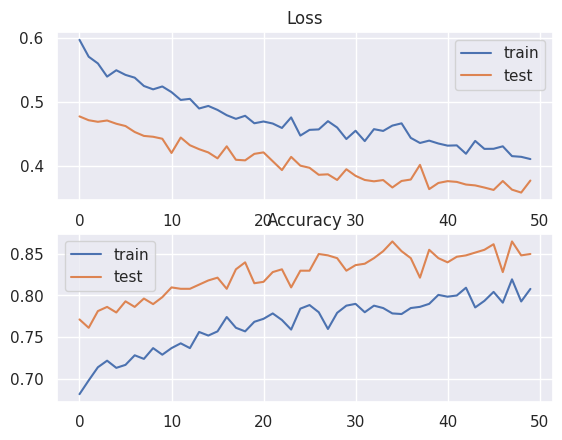

In [147]:
# plot loss during training
from matplotlib import pyplot
pyplot.subplot(211)
pyplot.title('Loss')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
# plot accuracy during training
pyplot.subplot(212)
pyplot.title('Accuracy')
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

# LSTM - AE

In [126]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

from numpy.random import seed

import tensorflow as tf

from keras.layers import Input, Dropout, Dense, LSTM, TimeDistributed, RepeatVector
from keras.models import Model
from keras import regularizers

In [130]:
from sklearn.model_selection import train_test_split
x_train1, x_test1 = train_test_split(X_res, test_size = 0.2, random_state = 0)

y_train1, y_test1 = train_test_split(y_res, test_size = 0.2, random_state = 0)

In [131]:
# normalize the data
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train1)
x_test = scaler.transform(x_test1)
scaler_filename = "scaler_data"
joblib.dump(scaler, scaler_filename)

['scaler_data']

In [132]:
# reshape inputs for LSTM [samples, timesteps, features]
X_train1 = x_train.reshape(x_train.shape[0], 1, x_train.shape[1])
print("Training data shape:", X_train1.shape)
X_test1 = x_test.reshape(x_test.shape[0], 1, x_test.shape[1])
print("Test data shape:", X_test1.shape)

Training data shape: (1595, 1, 17)
Test data shape: (399, 1, 17)


In [133]:
# define the autoencoder network model
def autoencoder_model(X):
    inputs = Input(shape=(X.shape[1], X.shape[2]))
    L1 = LSTM(16, activation='relu', return_sequences=True,
              kernel_regularizer=regularizers.l2(0.00))(inputs)
    L2 = LSTM(4, activation='relu', return_sequences=False)(L1)
    L3 = RepeatVector(X.shape[1])(L2)
    L4 = LSTM(4, activation='relu', return_sequences=True)(L3)
    L5 = LSTM(16, activation='relu', return_sequences=True)(L4)
    output = TimeDistributed(Dense(X.shape[2]))(L5)
    model = Model(inputs=inputs, outputs=output)
    return model

In [134]:
# create the autoencoder model
model_tl = autoencoder_model(X_train1)
model_tl.compile(optimizer='adam', loss='mae')
model_tl.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 1, 17)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 16)          │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 4)              │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 1, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 1, 4)           │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 16)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 1, 17)          │           289 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
nb_epochs = 50
batch_size = 2
history = model_tl.fit(X_train1, X_train1, epochs=nb_epochs, batch_size=batch_size,validation_split=0.05).history

Epoch 1/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.1750 - val_loss: 0.1409
Epoch 2/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1453 - val_loss: 0.1388
Epoch 3/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1446 - val_loss: 0.1381
Epoch 4/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1432 - val_loss: 0.1366
Epoch 5/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.1376 - val_loss: 0.1272
Epoch 6/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1274 - val_loss: 0.1215
Epoch 7/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1249 - val_loss: 0.1200
Epoch 8/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1239 - val_loss: 0.1186
Epoch 9/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1233 - val_loss: 0.1191
Epoch 10/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1229 - val_loss: 0.1188
Epoch 11/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1225 - val_loss: 0.1177
Epoch 12/50
758/758 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/ste

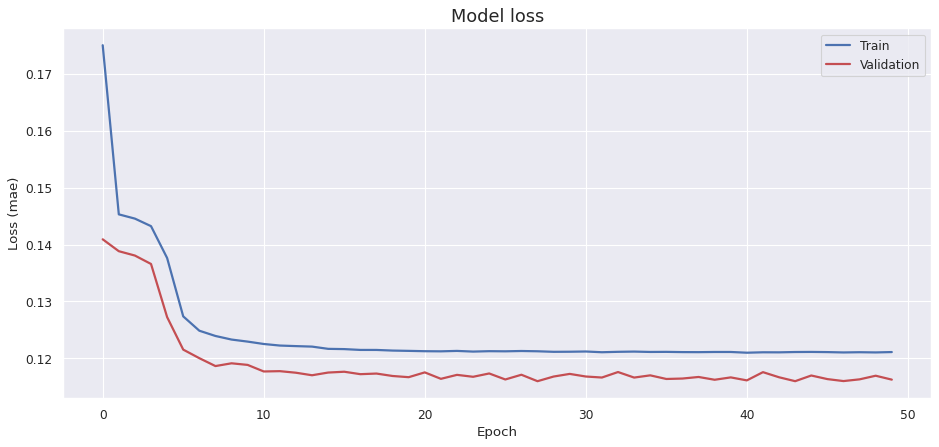

In [136]:
# plot the training losses
fig, ax = plt.subplots(figsize=(14, 6), dpi=80)
ax.plot(history['loss'], 'b', label='Train', linewidth=2)
ax.plot(history['val_loss'], 'r', label='Validation', linewidth=2)
ax.set_title('Model loss', fontsize=16)
ax.set_ylabel('Loss (mae)')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right')
plt.show()

In [156]:
y_pred=model_tl.predict(X_test1)
y_pred = np.argmax(y_pred,axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [157]:
X_test_pred = model_tl.predict(X_test1, verbose=0)
test_errors = np.mean(np.abs(X_test_pred - X_test1), axis=2).flatten()

X_train_pred = model_tl.predict(X_train1, verbose=0)
train_errors = np.mean(np.abs(X_train_pred - X_train1), axis=2).flatten()

threshold = np.max(train_errors) # Using max training error as threshold

y_pred_classified = (test_errors > threshold).astype(int)

tl_acc = accuracy_score(y_test1, y_pred_classified)
tl_prec = precision_score(y_test1, y_pred_classified, average='weighted')
tl_rec = recall_score(y_test1, y_pred_classified, average='weighted')
tl_f1 = f1_score(y_test1, y_pred_classified, average='weighted')

In [158]:
storeResults('LSTM-AE',tl_acc,tl_prec,tl_rec,tl_f1)

### Consolidated Model Performance Summary

In [159]:
# Re-initialize the lists to ensure a clean state and no duplicate entries
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

# Store results for each model (assuming individual metrics are available in the kernel)
storeResults('Logistic Regression', lr_acc, lr_prec, lr_rec, lr_f1)
storeResults('Random Forest', rf_acc, rf_prec, rf_rec, rf_f1)
storeResults('XGBoost', xgb_acc, xgb_prec, xgb_rec, xgb_f1)
storeResults('Stacking Classifier', stac_acc, stac_prec, stac_rec, stac_f1)
storeResults('Voting Classifier', vot_acc, vot_prec, vot_rec, vot_f1)
storeResults('RNN', rnn_acc, rnn_prec, rnn_rec, rnn_f1)
storeResults('LSTM-AE', tl_acc, tl_prec, tl_rec, tl_f1)

# Re-create and display the result DataFrame
result = pd.DataFrame({
    'ML Model' : ML_Model,
    'Accuracy' : accuracy,
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score': f1score
})

result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.729,0.729,0.729,0.729
1,Random Forest,0.892,0.893,0.892,0.892
2,XGBoost,0.915,0.916,0.915,0.915
3,Stacking Classifier,0.892,0.892,0.892,0.892
4,Voting Classifier,0.902,0.904,0.902,0.902
5,RNN,0.524,1.000,0.524,0.688
6,LSTM-AE,0.546,0.299,0.546,0.386


# Comparison

In [160]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score,

                      })

In [161]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.729,0.729,0.729,0.729
1,Random Forest,0.892,0.893,0.892,0.892
2,XGBoost,0.915,0.916,0.915,0.915
3,Stacking Classifier,0.892,0.892,0.892,0.892
4,Voting Classifier,0.902,0.904,0.902,0.902
5,RNN,0.524,1.000,0.524,0.688
6,LSTM-AE,0.546,0.299,0.546,0.386


# MOdelling

In [162]:
import joblib

filename1 = 'model.sav'

joblib.dump(eclf1, filename1)

['model.sav']

# Graph

In [163]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

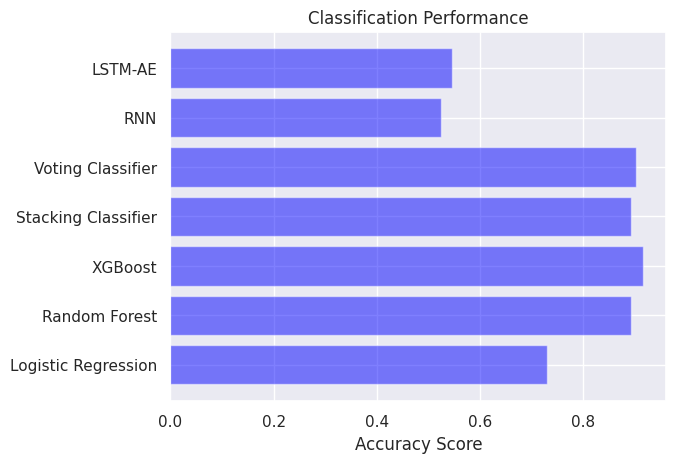

In [164]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

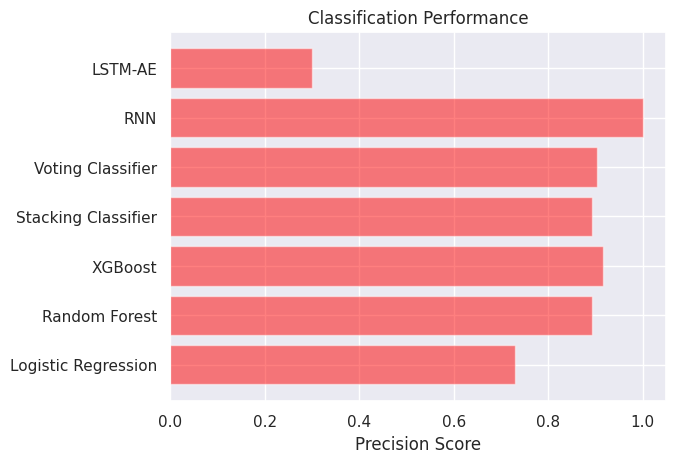

In [165]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

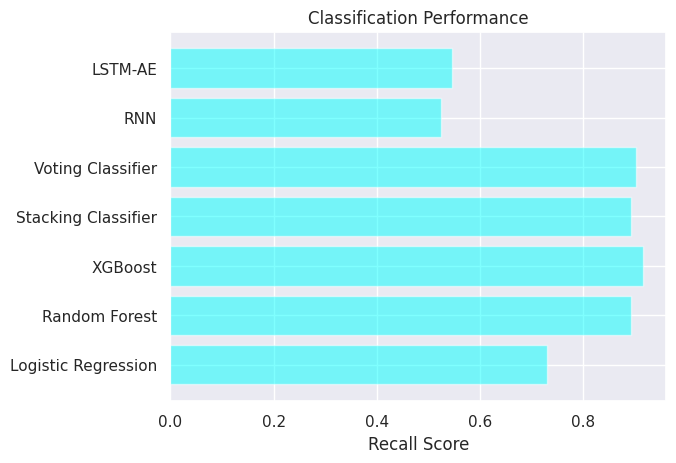

In [166]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='cyan')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

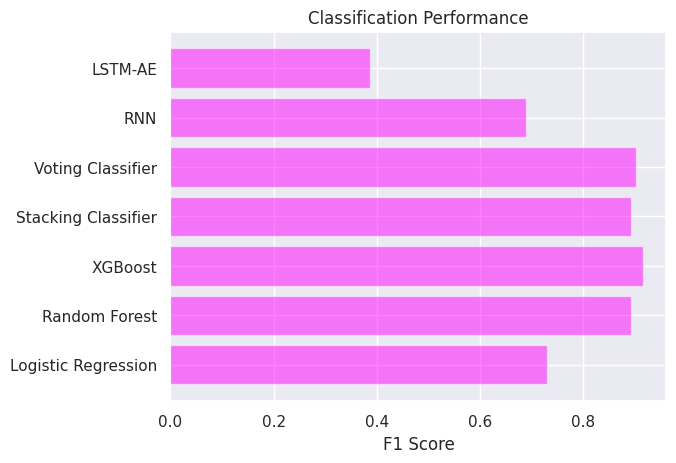

In [167]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()